In [1]:
import os
import numpy as np
from gwpy.timeseries import TimeSeries, TimeSeriesDict
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns

sns.set(style='whitegrid', context='paper')

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
# Detector configuration for both H1 and L1
detectors = {
    'H1': {
        'channel_name': 'H1:GW-H',
        't0_gps': 1126259462.423,
        'F_plus': 0.578742411175002,
        'F_cross': -0.45094782109531206,
        'color': 'blue'
    },
    'L1': {
        'channel_name': 'L1:GW-L',
        't0_gps': 1126259462.4160156,
        'F_plus': -0.5274334329518102,
        'F_cross': 0.20520960891727422,
        'color': 'orange'
    }
}

# Load time and strain data (once, shared by both detectors)
data_dir = 'h(t)'
time_data = np.loadtxt(os.path.join(data_dir, 't.txt'), delimiter=',')
hp_x = np.loadtxt(os.path.join(data_dir, 'hp_x.txt'))
hx_x = np.loadtxt(os.path.join(data_dir, 'hx_x.txt'))

# Calculate sample rate
dt = time_data[1] - time_data[0]
sample_rate = 1.0 / dt

# Process both detectors
timeseries_dict = {}
for det_name, det_params in detectors.items():
    # Combine polarizations: h = F+ * hp_x + Fx * hx_x
    h_strain = det_params['F_plus'] * hp_x + det_params['F_cross'] * hx_x
    
    # Calculate the duration and center time to make t0_gps the middle of the signal
    n_samples = len(h_strain)
    duration = (n_samples - 1) * dt
    t_start = det_params['t0_gps'] - duration / 2.0
    
    # Create TimeSeries
    timeseries_dict[det_name] = TimeSeries(
        h_strain, 
        sample_rate=sample_rate, 
        t0=t_start, 
        name=det_params['channel_name'], 
        unit='strain'
    )

print(f"Loaded data for detectors: {list(timeseries_dict.keys())}")
print(f"Sample rate: {sample_rate:.2f} Hz")
for det_name, ts in timeseries_dict.items():
    print(f"{det_name}: t0 = {ts.t0.value:.6f}, duration = {ts.duration.value:.3f}s")

Loaded data for detectors: ['H1', 'L1']
Sample rate: 10000.00 Hz
H1: t0 = 1126259450.423050, duration = 24.000s
L1: t0 = 1126259450.416066, duration = 24.000s


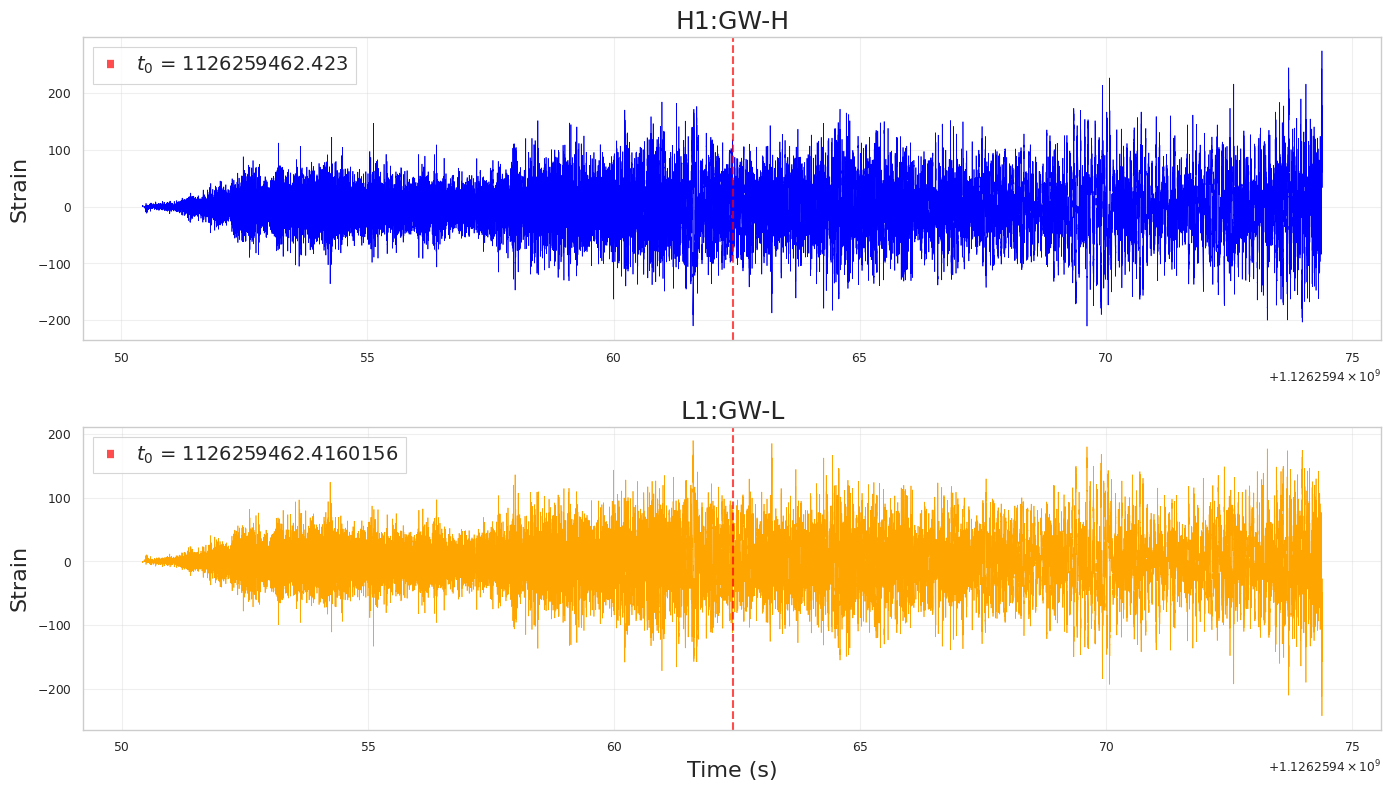

In [3]:
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

for idx, (det_name, ts) in enumerate(timeseries_dict.items()):
    ax = ax1 if idx == 0 else ax2
    det_params = detectors[det_name]
    t0_gps = det_params['t0_gps']
    color = det_params['color']
    
    ax.plot(ts.times.value, ts.value, linewidth=0.5, color=color)
    ax.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5, 
               label=f'$t_0$ = {t0_gps}', alpha=0.7)
    ax.set_ylabel('Strain', fontsize=16)
    ax.set_title(det_params['channel_name'], fontsize=18)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

ax2.set_xlabel('Time (s)', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# Scale and crop both detectors
ts_scaled_cropped = {}

for det_name, ts in timeseries_dict.items():
    t0_gps = detectors[det_name]['t0_gps']
    
    # Scale by 10^-23 and amplify by 5x
    ts_temp = ts * 1e-23 * 5
    
    # Crop to first 4 seconds from t0_gps
    ts_scaled_cropped[det_name] = ts_temp.crop(t0_gps, t0_gps + 4.0)
    
    print(f"{det_name}: {ts_scaled_cropped[det_name]}")

ts_scaled_cropped

H1: [-3.72383321e-22 -3.89355626e-22 -8.49351010e-23 ...
 -4.00392344e-21 -3.78804775e-21 -3.82201345e-21] strain
L1: [2.52202602e-22 2.76509617e-22 2.32133223e-23 ... 3.75608008e-21
 3.52620455e-21 3.58298792e-21] strain


{'H1': <TimeSeries([-3.72383321e-22, -3.89355626e-22, -8.49351010e-23,
              ..., -4.00392344e-21, -3.78804775e-21,
              -3.82201345e-21]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 9.98973846e-05 s>,
             name='H1:GW-H',
             channel=None)>,
 'L1': <TimeSeries([2.52202602e-22, 2.76509617e-22, 2.32133223e-23, ...,
              3.75608008e-21, 3.52620455e-21, 3.58298792e-21]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 9.98973846e-05 s>,
             name='L1:GW-L',
             channel=None)>}

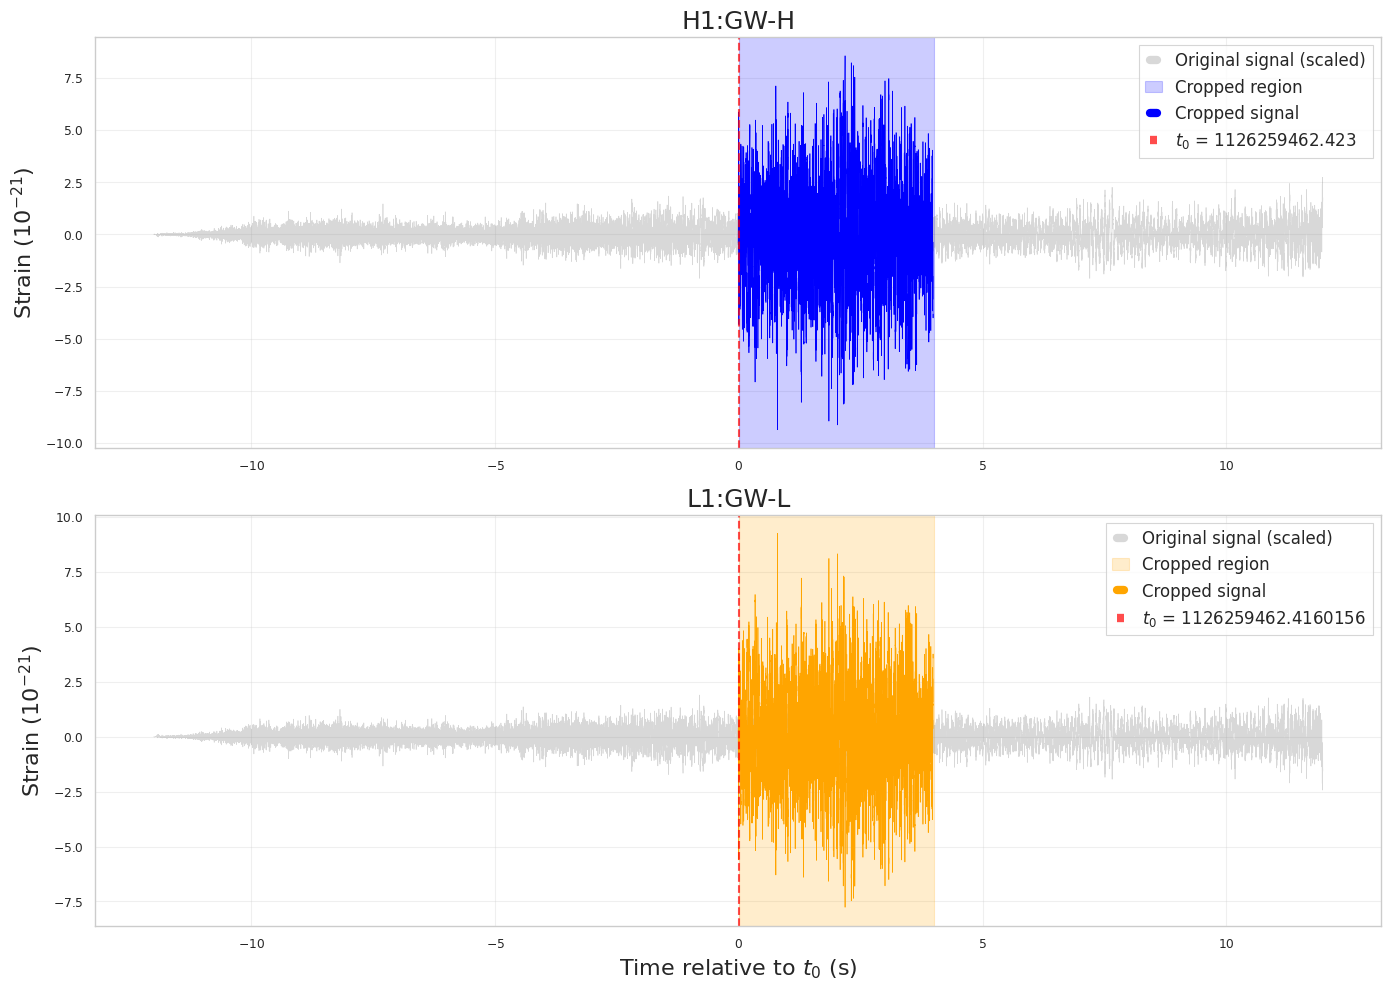

In [5]:
# Plot original and cropped signals for both detectors
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

for idx, (det_name, ts_cropped) in enumerate(ts_scaled_cropped.items()):
    ax = ax1 if idx == 0 else ax2
    det_params = detectors[det_name]
    t0_gps = det_params['t0_gps']
    color = det_params['color']
    ts_original = timeseries_dict[det_name]
    
    # Plot original signal (scaled)
    time_relative_original = ts_original.times.value - t0_gps
    ax.plot(time_relative_original, (ts_original * 1e-23).value / 1e-21, 
            linewidth=0.5, alpha=0.3, color='gray', label='Original signal (scaled)')
    
    # Shade the cropped region
    ax.axvspan(0, 4.0, alpha=0.2, color=color, label='Cropped region')
    
    # Plot cropped signal
    time_relative_cropped = ts_cropped.times.value - t0_gps
    ax.plot(time_relative_cropped, ts_cropped.value / 1e-21, 
            linewidth=0.5, color=color, label='Cropped signal')
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, 
               label=f'$t_0$ = {t0_gps}', alpha=0.7)
    ax.set_ylabel('Strain ($10^{-21}$)', fontsize=16)
    ax.set_title(det_params['channel_name'], fontsize=18)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

ax2.set_xlabel('Time relative to $t_0$ (s)', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Add 2 seconds of zeros before and after the signal for both detectors
ts_padded = {}

for det_name, ts_cropped in ts_scaled_cropped.items():
    t0_gps = detectors[det_name]['t0_gps']
    
    # Number of samples for 2 seconds
    n_zeros = int(2.0 * ts_cropped.sample_rate.value)
    
    # Create zero-padded data
    padded_data = np.concatenate([np.zeros(n_zeros), ts_cropped.value, np.zeros(n_zeros)])
    
    # Calculate t0 so that the middle of the padded signal is at t0_gps
    n_padded_samples = len(padded_data)
    padded_duration = (n_padded_samples - 1) / ts_cropped.sample_rate.value
    t_start_padded = t0_gps - padded_duration / 2.0
    
    # Create new TimeSeries with padded data
    ts_padded[det_name] = TimeSeries(
        padded_data, 
        sample_rate=ts_cropped.sample_rate.value, 
        t0=t_start_padded, 
        name=detectors[det_name]['channel_name'], 
        unit='strain'
    )
    
    print(f"{det_name}: {ts_padded[det_name]}")

ts_padded

H1: [0. 0. 0. ... 0. 0. 0.] strain
L1: [0. 0. 0. ... 0. 0. 0.] strain


{'H1': <TimeSeries([0., 0., 0., ..., 0., 0., 0.]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 9.98973846e-05 s>,
             name='H1:GW-H',
             channel=None)>,
 'L1': <TimeSeries([0., 0., 0., ..., 0., 0., 0.]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 9.98973846e-05 s>,
             name='L1:GW-L',
             channel=None)>}

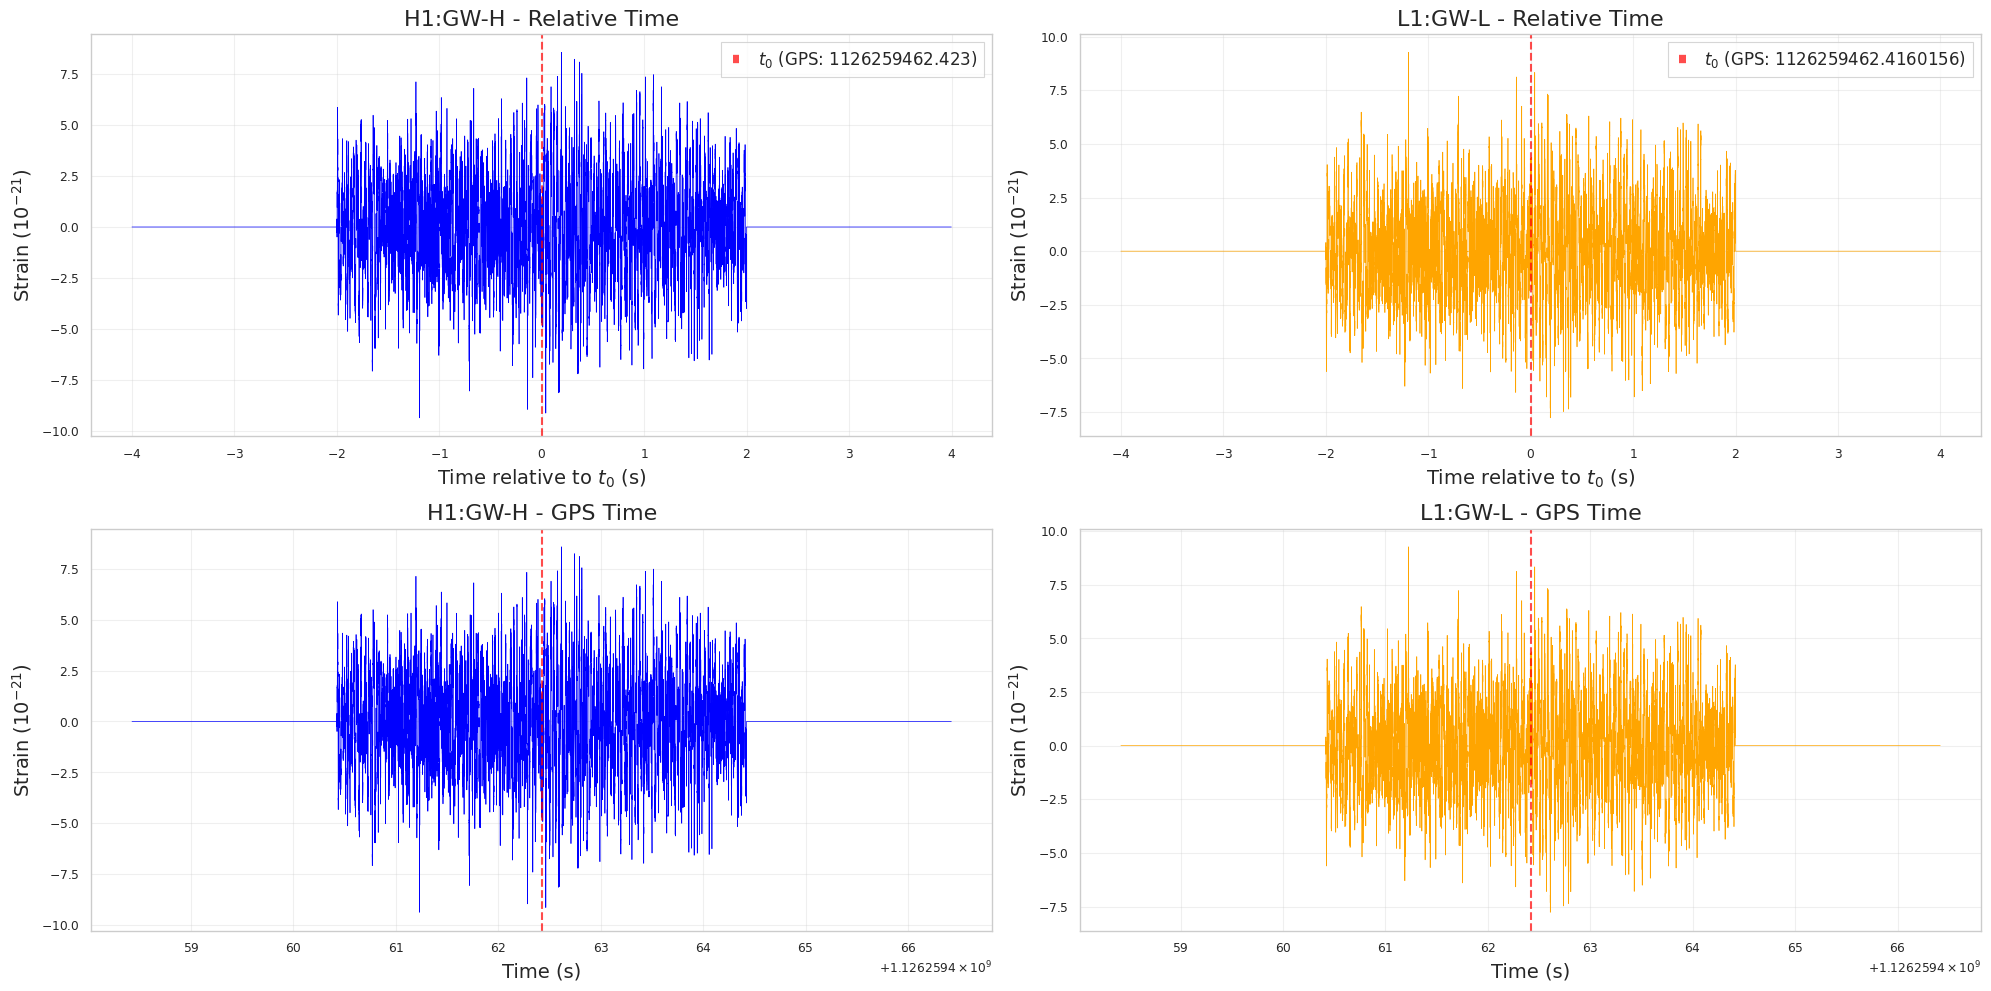

In [7]:
# Plot padded signals for both detectors
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

for col_idx, (det_name, ts) in enumerate(ts_padded.items()):
    det_params = detectors[det_name]
    t0_gps = det_params['t0_gps']
    color = det_params['color']
    
    # Top panel: relative time
    ax_top = axes[0, col_idx]
    time_relative = ts.times.value - t0_gps
    ax_top.plot(time_relative, ts.value / 1e-21, linewidth=0.5, color=color)
    ax_top.axvline(x=0, color='red', linestyle='--', linewidth=1.5, 
                   label=f'$t_0$ (GPS: {t0_gps})', alpha=0.7)
    ax_top.set_xlabel('Time relative to $t_0$ (s)', fontsize=14)
    ax_top.set_ylabel('Strain ($10^{-21}$)', fontsize=14)
    ax_top.set_title(f'{det_params["channel_name"]} - Relative Time', fontsize=16)
    ax_top.legend(fontsize=12)
    ax_top.grid(True, alpha=0.3)
    
    # Bottom panel: GPS time
    ax_bottom = axes[1, col_idx]
    ax_bottom.plot(ts.times.value, ts.value / 1e-21, linewidth=0.5, color=color)
    ax_bottom.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax_bottom.set_xlabel('Time (s)', fontsize=14)
    ax_bottom.set_ylabel('Strain ($10^{-21}$)', fontsize=14)
    ax_bottom.set_title(f'{det_params["channel_name"]} - GPS Time', fontsize=16)
    ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Decimate to 4096 Hz and apply Tukey taper for both detectors
ts_before_decimation = {}
ts_final = {}

for det_name, ts in ts_padded.items():
    # Save before decimation for comparison
    ts_before_decimation[det_name] = ts.copy()
    
    print(f"\n{det_name}:")
    print(f"  Before decimation: {ts_before_decimation[det_name].sample_rate.value} Hz, {len(ts_before_decimation[det_name])} samples")
    print(f"  t0 before decimation: {ts_before_decimation[det_name].t0.value}")
    
    # Decimate to 4096 Hz using FIR filter to avoid phase shift
    decimation_factor = int(ts.sample_rate.value / 4096)
    print(f"  Decimation factor: {decimation_factor}")
    
    # Use FIR filter with zero_phase=True to avoid time shift
    data_decimated = signal.decimate(ts.value, decimation_factor, ftype='fir', zero_phase=True)
    ts_temp = TimeSeries(data_decimated, sample_rate=4096, t0=ts_before_decimation[det_name].t0, 
                         name=detectors[det_name]['channel_name'], unit='strain')
    
    # Apply Tukey taper
    ts_tapered = ts_temp * signal.windows.tukey(len(ts_temp), alpha=0.1)
    
    print(f"  After decimation: {ts_tapered.sample_rate.value} Hz, {len(ts_tapered)} samples")
    print(f"  Duration after decimation: {ts_tapered.duration.value} seconds")
    
    # Pad to exactly 10 seconds
    target_duration = 10.0  # seconds
    target_samples = int(target_duration * ts_tapered.sample_rate.value)
    current_samples = len(ts_tapered)
    
    if current_samples < target_samples:
        # Add zeros at the end
        zeros_needed = target_samples - current_samples
        padded_data = np.concatenate([ts_tapered.value, np.zeros(zeros_needed)])
        
        ts_final[det_name] = TimeSeries(
            padded_data,
            sample_rate=ts_tapered.sample_rate.value,
            t0=ts_tapered.t0.value,
            name=detectors[det_name]['channel_name'],
            unit='strain'
        )
        print(f"  Added {zeros_needed} zeros at the end")
    else:
        ts_final[det_name] = ts_tapered
    
    print(f"  Final: {ts_final[det_name].sample_rate.value} Hz, {len(ts_final[det_name])} samples")
    print(f"  Final duration: {ts_final[det_name].duration.value} seconds")
    print(f"  t0 final: {ts_final[det_name].t0.value}")

ts_final


H1:
  Before decimation: 10010.272076372315 Hz, 80040 samples
  t0 before decimation: 1126259458.4251566
  Decimation factor: 2
  After decimation: 4096.0 Hz, 40020 samples
  Duration after decimation: 9.7705078125 seconds
  Added 940 zeros at the end
  Final: 4096.0 Hz, 40960 samples
  Final duration: 10.0 seconds
  t0 final: 1126259458.4251566

L1:
  Before decimation: 10010.272076372315 Hz, 80040 samples
  t0 before decimation: 1126259458.4181724
  Decimation factor: 2
  After decimation: 4096.0 Hz, 40020 samples
  Duration after decimation: 9.7705078125 seconds
  Added 940 zeros at the end
  Final: 4096.0 Hz, 40960 samples
  Final duration: 10.0 seconds
  t0 final: 1126259458.4181724


{'H1': <TimeSeries([0., 0., 0., ..., 0., 0., 0.]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 0.00024414 s>,
             name='H1:GW-H',
             channel=None)>,
 'L1': <TimeSeries([0., 0., 0., ..., 0., 0., 0.]
             unit=Unit("strain"),
             t0=<Quantity 1.12625946e+09 s>,
             dt=<Quantity 0.00024414 s>,
             name='L1:GW-L',
             channel=None)>}

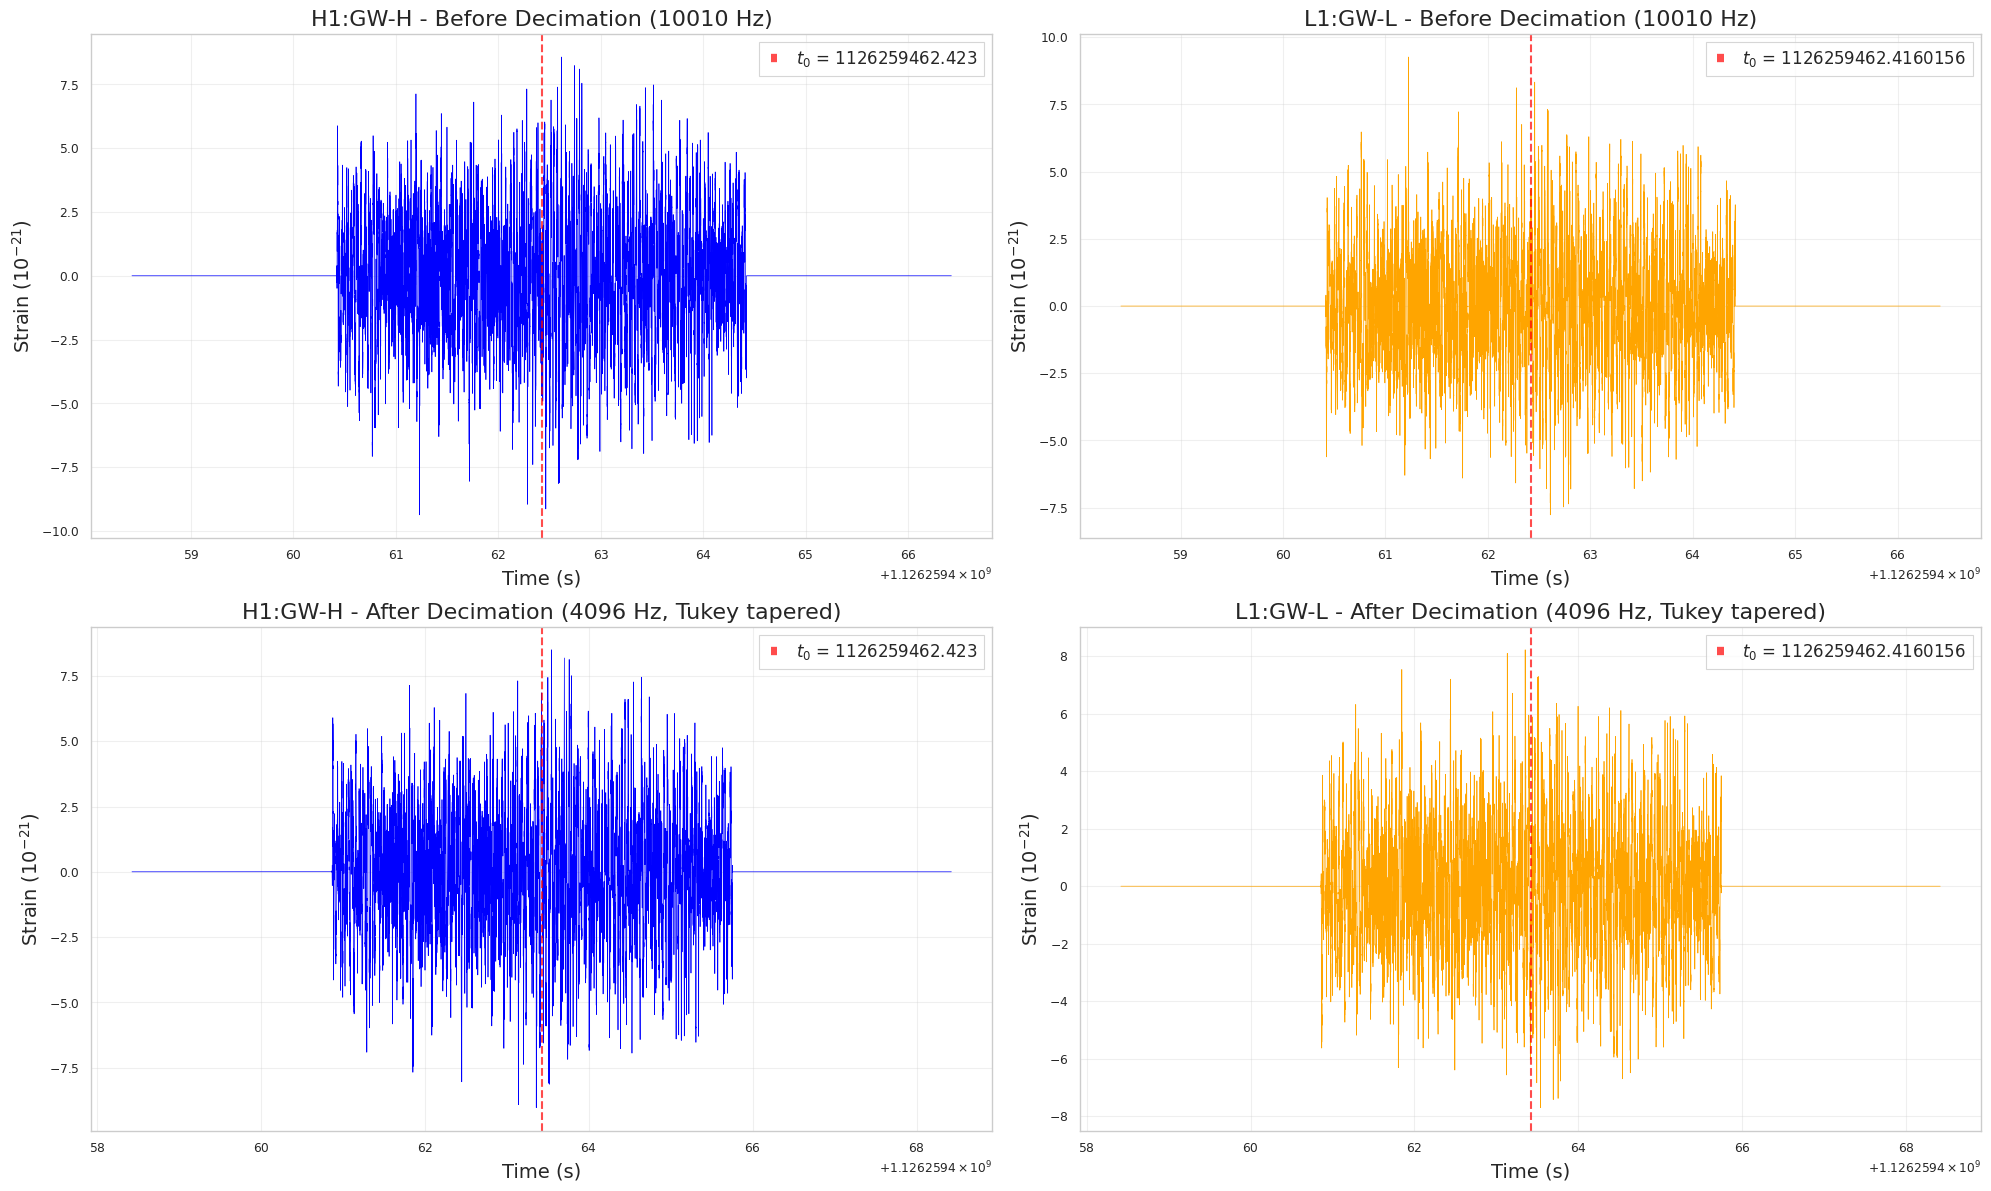

In [9]:
# Comparison plot: before and after decimation for both detectors
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for col_idx, det_name in enumerate(ts_final.keys()):
    det_params = detectors[det_name]
    t0_gps = det_params['t0_gps']
    color = det_params['color']
    
    ts_before = ts_before_decimation[det_name]
    ts_after = ts_final[det_name]
    
    # Before decimation (top row)
    ax_before = axes[0, col_idx]
    ax_before.plot(ts_before.times.value, ts_before.value / 1e-21, 
                   linewidth=0.5, color=color)
    ax_before.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5, 
                      label=f'$t_0$ = {t0_gps}', alpha=0.7)
    ax_before.set_xlabel('Time (s)', fontsize=14)
    ax_before.set_ylabel('Strain ($10^{-21}$)', fontsize=14)
    ax_before.set_title(f'{det_params["channel_name"]} - Before Decimation ({ts_before.sample_rate.value:.0f} Hz)', 
                        fontsize=16)
    ax_before.legend(fontsize=12)
    ax_before.grid(True, alpha=0.3)
    
    # After decimation (bottom row)
    ax_after = axes[1, col_idx]
    ax_after.plot(ts_after.times.value, ts_after.value / 1e-21, 
                  linewidth=0.5, color=color)
    ax_after.axvline(x=ts_after.t0.value + (ts_after.duration.value / 2), 
                     color='red', linestyle='--', linewidth=1.5, 
                     label=f'$t_0$ = {t0_gps}', alpha=0.7)
    ax_after.set_xlabel('Time (s)', fontsize=14)
    ax_after.set_ylabel('Strain ($10^{-21}$)', fontsize=14)
    ax_after.set_title(f'{det_params["channel_name"]} - After Decimation (4096 Hz, Tukey tapered)', 
                       fontsize=16)
    ax_after.legend(fontsize=12)
    ax_after.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Save frame files for both detectors
for det_name, ts in ts_final.items():
    filename = f'{det_name}.gwf'
    ts.write(filename, format='gwf')
    print(f"Written {len(ts)} samples at {ts.sample_rate.value} Hz to {filename}")
    print(f"  Total duration: {ts.duration.value} seconds")
    print(f"  t0: {ts.t0.value}")

Written 40960 samples at 4096.0 Hz to H1.gwf
  Total duration: 10.0 seconds
  t0: 1126259458.4251566
Written 40960 samples at 4096.0 Hz to L1.gwf
  Total duration: 10.0 seconds
  t0: 1126259458.4181724


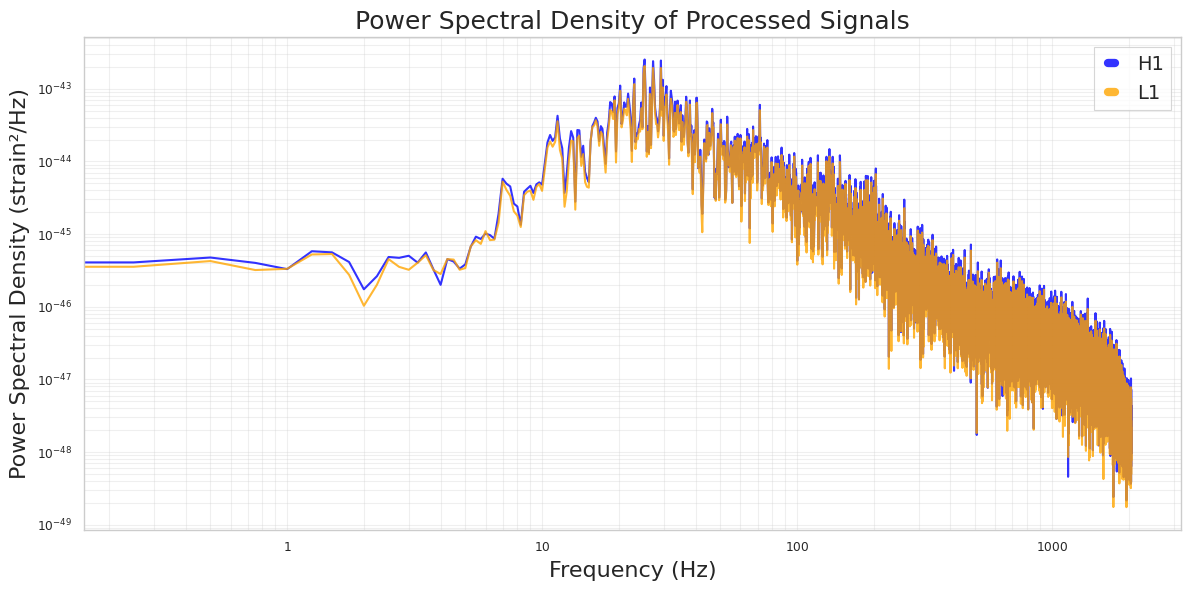

PSD calculated with 4s FFT length and 2s overlap
Frequency resolution: 0.25 Hz
Saved PSD to H1_psd.dat
  Frequency range: 0.00 - 2047.75 Hz
  Number of bins: 8192, N*df = 2048.00 Hz
Saved PSD to L1_psd.dat
  Frequency range: 0.00 - 2047.75 Hz
  Number of bins: 8192, N*df = 2048.00 Hz


In [11]:
# Calculate PSD (Power Spectral Density) for both detectors using Welch's method
fftlength = 4  # FFT length in seconds
overlap = 2    # Overlap in seconds

psd_dict = {}

# Calculate PSDs
for det_name, ts in ts_final.items():
    psd_dict[det_name] = ts.psd(fftlength=fftlength, overlap=overlap)

# Plot overlaid PSDs
plt.figure(figsize=(12, 6))
for det_name, psd in psd_dict.items():
    color = detectors[det_name]['color']
    plt.loglog(psd.frequencies.value, psd.value, linewidth=1.5, 
               color=color, label=det_name, alpha=0.8)

plt.xlabel('Frequency (Hz)', fontsize=16)
plt.ylabel('Power Spectral Density (strain²/Hz)', fontsize=16)
plt.title('Power Spectral Density of Processed Signals', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"PSD calculated with {fftlength}s FFT length and {overlap}s overlap")
print(f"Frequency resolution: {psd_dict['H1'].df.value} Hz")

# Save PSDs to separate files
# Previously, there's BayesWave error message: 4096.25 Hz != 4096 Hz
# BayesWave expects N*df = f_nyquist, but gwpy includes the Nyquist bin
# So we need N-1 bins: (N-1)*df = f_nyquist
for det_name, psd in psd_dict.items():
    filename = f'{det_name}_psd.dat'
    # Remove the last frequency bin (Nyquist frequency)
    psd_truncated = psd[:-1]
    np.savetxt(filename, np.column_stack([psd_truncated.frequencies.value, psd_truncated.value]), delimiter=' ')
    print(f"Saved PSD to {filename}")
    print(f"  Frequency range: {psd_truncated.frequencies.value[0]:.2f} - {psd_truncated.frequencies.value[-1]:.2f} Hz")
    print(f"  Number of bins: {len(psd_truncated)}, N*df = {len(psd_truncated) * psd_truncated.df.value:.2f} Hz")